## 8. Mini analiza danych z poprzednich zajęć

Teraz przechodzimy z danych syntetycznych na mały zbiór z poprzednich zajęć: `previous_lecture_grades.csv`.

Cel tej sekcji nie jest „zbudować najlepszy model”, tylko przećwiczyć ten sam sposób myślenia:

$$
\text{dane} \rightarrow \text{czyszczenie} \rightarrow \text{target} \rightarrow \text{baseline} \rightarrow \text{model} \rightarrow \text{interpretacja}
$$

Dodatkowo wykorzystamy ten przykład do pokazania, dlaczego **odds ratio** i **log odds ratio** są wygodne w klasyfikacji.

In [10]:
from pathlib import Path

csv_path = Path('previous_lecture_grades.csv')

# Notebook najlepiej uruchamiać w tym samym katalogu co plik CSV.
# Mały fallback poniżej sprawia, że sekcja nadal działa, jeśli ktoś otworzy sam notebook bez pliku.
if csv_path.exists():
    grades_raw = pd.read_csv(csv_path)
else:
    grades_raw = pd.DataFrame({
        'Name': ['Dan', 'Joann', 'Pedro', 'Rosie', 'Ethan', 'Vicky', 'Frederic', 'Jimmie', 'Rhonda',
                 'Giovanni', 'Francesca', 'Rajab', 'Naiyana', 'Kian', 'Jenny', 'Jakeem', 'Helena',
                 'Ismat', 'Anila', 'Skye', 'Daniel', 'Aisha', 'Bill', 'Ted'],
        'StudyHours': [10, 11.5, 9, 16, 9.25, 1, 11.5, 9, 8.5, 14.5, 15.5, 13.75,
                       9, 8, 15.5, 8, 9, 6, 10, 12, 12.5, 12, 8, np.nan],
        'Grade': [50, 50, 47, 97, 49, 3, 53, 42, 26, 74, 82, 62,
                  37, 15, 70, 27, 36, 35, 48, 52, 63, 64, np.nan, np.nan]
    })

grades_raw

,Name,StudyHours,Grade
0,Dan,10.00,50.0
1,Joann,11.50,50.0
2,Pedro,9.00,47.0
3,Rosie,16.00,97.0
4,Ethan,9.25,49.0
5,Vicky,1.00,3.0
6,Frederic,11.50,53.0
7,Jimmie,9.00,42.0
8,Rhonda,8.50,26.0
9,Giovanni,14.50,74.0


### 8.1. Czyszczenie i definicja targetu

W pliku są trzy kolumny:

- `Name` — imię studenta,
- `StudyHours` — liczba godzin nauki,
- `Grade` — wynik punktowy.

Do prostej klasyfikacji definiujemy:

$$
Pass50 = 1 \quad \text{gdy} \quad Grade \ge 50
$$

czyli traktujemy wynik `50` jako próg zaliczenia.

In [11]:
missing_table = grades_raw.isna().sum().to_frame('missing_values')
missing_table

,missing_values
Name,0
StudyHours,1
Grade,2


In [12]:
grades = grades_raw.dropna(subset=['StudyHours', 'Grade']).copy()
grades['Pass50'] = (grades['Grade'] >= 50).astype(int)

print('Liczba wierszy przed czyszczeniem:', len(grades_raw))
print('Liczba wierszy po czyszczeniu:', len(grades))
print('\nLiczba osób w klasach:')
print(grades['Pass50'].value_counts().rename(index={0: 'Fail', 1: 'Pass'}))

grades[['Name', 'StudyHours', 'Grade', 'Pass50']]

Liczba wierszy przed czyszczeniem: 24
Liczba wierszy po czyszczeniu: 22

Liczba osób w klasach:
Pass50
Pass    11
Fail    11
Name: count, dtype: int64


,Name,StudyHours,Grade,Pass50
0,Dan,10.00,50.0,1
1,Joann,11.50,50.0,1
2,Pedro,9.00,47.0,0
3,Rosie,16.00,97.0,1
4,Ethan,9.25,49.0,0
5,Vicky,1.00,3.0,0
6,Frederic,11.50,53.0,1
7,Jimmie,9.00,42.0,0
8,Rhonda,8.50,26.0,0
9,Giovanni,14.50,74.0,1


### 8.2. Szybki obraz danych

Zaczynamy od najprostszego wykresu: `StudyHours` kontra `Grade`.

Linia pozioma pokazuje próg zaliczenia `Grade = 50`.  
Linia pionowa pokazuje przykładowy próg `StudyHours = 10`, którego później użyjemy do policzenia odds ratio.

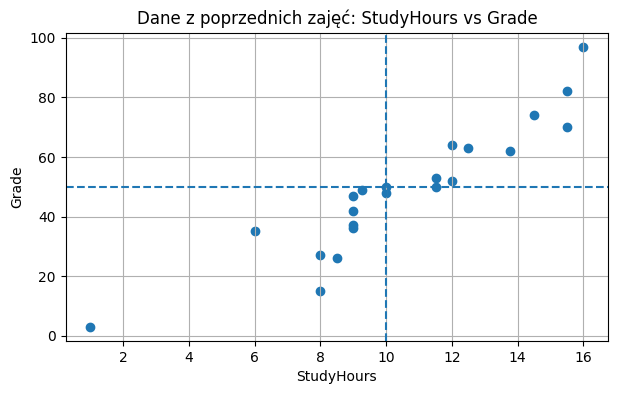

In [13]:
plt.figure(figsize=(7, 4))
plt.scatter(grades['StudyHours'], grades['Grade'])
plt.axhline(50, linestyle='--')
plt.axvline(10, linestyle='--')
plt.xlabel('StudyHours')
plt.ylabel('Grade')
plt.title('Dane z poprzednich zajęć: StudyHours vs Grade')
plt.grid(True)
plt.show()

### 8.3. Regresja: baseline kontra model liniowy

Najpierw traktujemy `Grade` jako problem regresyjny.

Użyjemy tylko jednej cechy:

$$
X = StudyHours
$$

Baseline przewiduje zawsze średnią ocenę z treningu. Model liniowy próbuje użyć informacji o liczbie godzin nauki.

Uwaga: to jest bardzo mały zbiór danych, więc wynik train/test może zależeć od konkretnego podziału. To jest dobry pretekst do rozmowy o cross-validation.

In [14]:
X_small = grades[['StudyHours']]
y_grade = grades['Grade']
y_pass = grades['Pass50']

X_train_s, X_test_s, y_train_grade_s, y_test_grade_s, y_train_pass_s, y_test_pass_s = train_test_split(
    X_small,
    y_grade,
    y_pass,
    test_size=0.30,
    random_state=4,
    stratify=y_pass
)

baseline_grade_pred = np.repeat(y_train_grade_s.mean(), len(y_test_grade_s))

lin_small = LinearRegression()
lin_small.fit(X_train_s, y_train_grade_s)
lin_grade_pred = lin_small.predict(X_test_s)

reg_small_results = pd.DataFrame({
    'model': ['baseline_mean', 'linear_regression_StudyHours'],
    'MAE': [
        mean_absolute_error(y_test_grade_s, baseline_grade_pred),
        mean_absolute_error(y_test_grade_s, lin_grade_pred)
    ],
    'RMSE': [
        mean_squared_error(y_test_grade_s, baseline_grade_pred) ** 0.5,
        mean_squared_error(y_test_grade_s, lin_grade_pred) ** 0.5
    ],
    'R2': [
        r2_score(y_test_grade_s, baseline_grade_pred),
        r2_score(y_test_grade_s, lin_grade_pred)
    ]
})

reg_small_results

,model,MAE,RMSE,R2
0,baseline_mean,10.7238,13.6624,-0.0007
1,linear_regression_StudyHours,6.5121,6.7001,0.7593


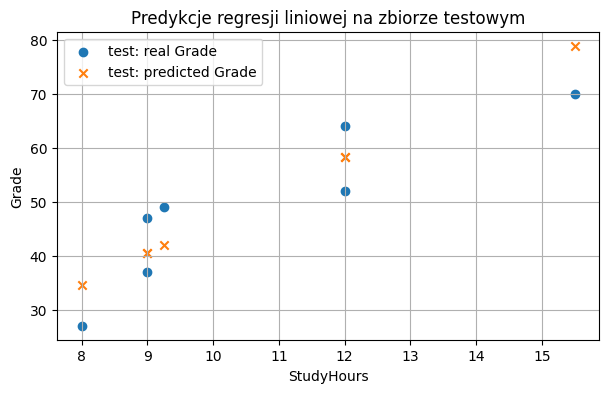

In [15]:
plt.figure(figsize=(7, 4))
plt.scatter(X_test_s['StudyHours'], y_test_grade_s, label='test: real Grade')
plt.scatter(X_test_s['StudyHours'], lin_grade_pred, marker='x', label='test: predicted Grade')
plt.xlabel('StudyHours')
plt.ylabel('Grade')
plt.title('Predykcje regresji liniowej na zbiorze testowym')
plt.legend()
plt.grid(True)
plt.show()

### 8.4. Klasyfikacja: baseline kontra regresja logistyczna

Teraz zmieniamy problem:

$$
Pass50 \in \{0, 1\}
$$

Baseline przewiduje najczęstszą klasę z treningu. Regresja logistyczna używa `StudyHours`, żeby oszacować prawdopodobieństwo zaliczenia.

In [16]:
majority_pass = int(y_train_pass_s.mode()[0])
baseline_pass_pred = np.repeat(majority_pass, len(y_test_pass_s))

log_small = LogisticRegression(max_iter=1000)
log_small.fit(X_train_s, y_train_pass_s)

pass_proba_s = log_small.predict_proba(X_test_s)[:, 1]
pass_pred_s = (pass_proba_s >= 0.5).astype(int)

cls_small_results = pd.DataFrame({
    'model': ['baseline_majority', 'logistic_regression_StudyHours'],
    'accuracy': [
        accuracy_score(y_test_pass_s, baseline_pass_pred),
        accuracy_score(y_test_pass_s, pass_pred_s)
    ],
    'AUC': [
        np.nan,
        roc_auc_score(y_test_pass_s, pass_proba_s)
    ]
})

cls_small_results

,model,accuracy,AUC
0,baseline_majority,0.4286,NaN
1,logistic_regression_StudyHours,1.0000,1.0


In [17]:
cm_small = confusion_matrix(y_test_pass_s, pass_pred_s)
pd.DataFrame(
    cm_small,
    index=['actual_0_fail', 'actual_1_pass'],
    columns=['pred_0_fail', 'pred_1_pass']
)

,pred_0_fail,pred_1_pass
actual_0_fail,4,0
actual_1_pass,0,3


### 8.5. Cross-validation na małym zbiorze

Ponieważ mamy tylko 22 kompletne obserwacje, jeden podział train/test może być przypadkowo łatwy albo trudny.

Dlatego sprawdzamy prosty model liniowy również przez 5-fold cross-validation.

In [18]:
kfold_small = KFold(n_splits=5, shuffle=True, random_state=123)

cv_scores_small = cross_val_score(
    LinearRegression(),
    X_small,
    y_grade,
    cv=kfold_small,
    scoring='r2'
)

cv_small_summary = pd.DataFrame({
    'fold': np.arange(1, len(cv_scores_small) + 1),
    'R2': cv_scores_small
})

print('Średnie R2:', round(cv_scores_small.mean(), 3))
print('Odchylenie R2:', round(cv_scores_small.std(), 3))

cv_small_summary

Średnie R2: 0.728
Odchylenie R2: 0.123


,fold,R2
0,1,0.8773
1,2,0.7712
2,3,0.5403
3,4,0.8167
4,5,0.6334


### 8.6. Odds ratio dla prostego progu godzin nauki

Teraz robimy bardzo prostą analizę dyskretną.

Dzielimy studentów na dwie grupy:

$$
StudyHours \ge 10 \quad \text{versus} \quad StudyHours < 10
$$

Dla każdej grupy liczymy odds zaliczenia:

$$
odds = \frac{\text{liczba zdanych}}{\text{liczba niezdanych}}
$$

A potem:

$$
OR = \frac{odds(+)}{odds(-)}
$$

gdzie `+` oznacza grupę z większą liczbą godzin nauki.

In [19]:
grades['HighHours10'] = (grades['StudyHours'] >= 10).astype(int)

ct_hours = pd.crosstab(
    grades['HighHours10'].map({0: 'StudyHours < 10', 1: 'StudyHours >= 10'}),
    grades['Pass50'].map({0: 'Fail', 1: 'Pass'}),
    margins=True
)

ct_hours

Pass50,Fail,Pass,All
HighHours10,,,
StudyHours < 10,10,0,10
StudyHours >= 10,1,11,12
All,11,11,22


In [20]:
# Tabela bez etykiet tekstowych, wygodniejsza do liczenia
ct = pd.crosstab(grades['HighHours10'], grades['Pass50']).reindex(index=[0, 1], columns=[0, 1], fill_value=0)

fail_low, pass_low = ct.loc[0, 0], ct.loc[0, 1]
fail_high, pass_high = ct.loc[1, 0], ct.loc[1, 1]

# Bez korekty: tutaj odds w grupie <10h wynosi 0, więc OR robi się nieskończone.
odds_high_raw = pass_high / fail_high if fail_high != 0 else np.inf
odds_low_raw = pass_low / fail_low if fail_low != 0 else np.inf
OR_raw = odds_high_raw / odds_low_raw if odds_low_raw != 0 else np.inf
log_OR_raw = np.log(OR_raw)

# Mała korekta 0.5, często stosowana przy zerach w tabelach 2x2.
c = 0.5
odds_high_corr = (pass_high + c) / (fail_high + c)
odds_low_corr = (pass_low + c) / (fail_low + c)
OR_corr = odds_high_corr / odds_low_corr
log_OR_corr = np.log(OR_corr)

odds_10h_summary = pd.DataFrame({
    'wariant': ['bez korekty', 'korekta +0.5'],
    'odds(+)': [odds_high_raw, odds_high_corr],
    'odds(-)': [odds_low_raw, odds_low_corr],
    'OR': [OR_raw, OR_corr],
    'log(OR)': [log_OR_raw, log_OR_corr]
})

odds_10h_summary

,wariant,odds(+),odds(-),OR,log(OR)
0,bez korekty,11.0000,0.0000,inf,inf
1,korekta +0.5,7.6667,0.0476,161.0,5.0814


W tym zbiorze próg `10` godzin prawie idealnie rozdziela klasy.

To jest dydaktycznie ciekawe, ale technicznie powoduje problem: w grupie `StudyHours < 10` nikt nie zdał, więc `odds(-) = 0` i zwykłe `OR` robi się nieskończone.

Dlatego w drugim wierszu dodajemy małą korektę `0.5`. Nie zmienia ona intuicji, ale pozwala policzyć skończone wartości.

### 8.7. Pętla po progach: OR i log(OR)

Teraz powtarzamy ten sam rachunek dla kilku progów liczby godzin nauki.

Dzięki temu widać, że `OR` może zmieniać się bardzo gwałtownie, a `log(OR)` przenosi wynik na spokojniejszą, addytywną skalę.

In [21]:
thresholds = [6, 8, 9, 10, 11.5, 12, 13, 14, 15]
rows = []

for threshold in thresholds:
    high = grades['StudyHours'] >= threshold
    passed = grades['Pass50'] == 1

    pass_high = (high & passed).sum()
    fail_high = (high & ~passed).sum()
    pass_low = (~high & passed).sum()
    fail_low = (~high & ~passed).sum()

    # korekta 0.5 zabezpiecza przed dzieleniem przez zero
    c = 0.5
    odds_plus = (pass_high + c) / (fail_high + c)
    odds_minus = (pass_low + c) / (fail_low + c)
    OR = odds_plus / odds_minus
    log_OR = np.log(OR)

    rows.append({
        'threshold': threshold,
        'pass_high': pass_high,
        'fail_high': fail_high,
        'pass_low': pass_low,
        'fail_low': fail_low,
        'odds(+)': odds_plus,
        'odds(-)': odds_minus,
        'OR': OR,
        'log(OR)': log_OR
    })

or_by_threshold = pd.DataFrame(rows)
or_by_threshold

,threshold,pass_high,fail_high,pass_low,fail_low,odds(+),odds(-),OR,log(OR)
0,6.0,11,10,0,1,1.0952,0.3333,3.2857,1.1896
1,8.0,11,9,0,2,1.2105,0.2000,6.0526,1.8005
2,9.0,11,6,0,5,1.7692,0.0909,19.4615,2.9684
3,10.0,11,1,0,10,7.6667,0.0476,161.0000,5.0814
4,11.5,10,0,1,11,21.0000,0.1304,161.0000,5.0814
5,12.0,8,0,3,11,17.0000,0.3043,55.8571,4.0228
6,13.0,5,0,6,11,11.0000,0.5652,19.4615,2.9684
7,14.0,4,0,7,11,9.0000,0.6522,13.8000,2.6247
8,15.0,3,0,8,11,7.0000,0.7391,9.4706,2.2482


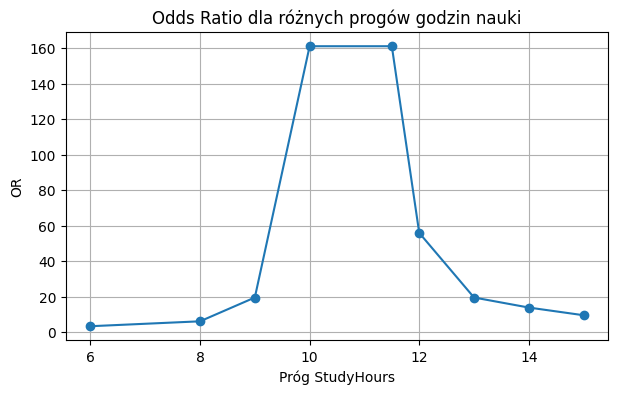

In [22]:
plt.figure(figsize=(7, 4))
plt.plot(or_by_threshold['threshold'], or_by_threshold['OR'], marker='o')
plt.xlabel('Próg StudyHours')
plt.ylabel('OR')
plt.title('Odds Ratio dla różnych progów godzin nauki')
plt.grid(True)
plt.show()

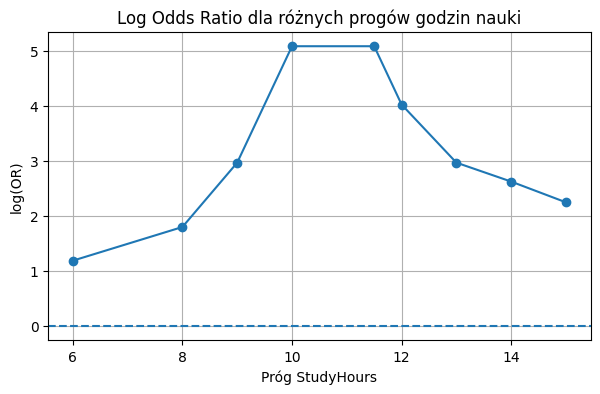

In [23]:
plt.figure(figsize=(7, 4))
plt.plot(or_by_threshold['threshold'], or_by_threshold['log(OR)'], marker='o')
plt.axhline(0, linestyle='--')
plt.xlabel('Próg StudyHours')
plt.ylabel('log(OR)')
plt.title('Log Odds Ratio dla różnych progów godzin nauki')
plt.grid(True)
plt.show()

### 8.8. Same wartości: logarytm prostuje skalę multiplikatywną

To jest najprostsza wersja intuicji.

Jeżeli `OR` zmienia się przez mnożenie razy `2`:

$$
\frac{1}{16}, \frac{1}{8}, \frac{1}{4}, \frac{1}{2}, 1, 2, 4, 8, 16
$$

to `log(OR)` zmienia się przez dodawanie stałej wartości:

$$
\log(2) \approx 0.693
$$

Czyli logarytm zamienia skalę multiplikatywną na addytywną.

In [24]:
OR_values = np.array([1/16, 1/8, 1/4, 1/2, 1, 2, 4, 8, 16])
log_OR_values = np.log(OR_values)

value_table = pd.DataFrame({
    'step': np.arange(len(OR_values)),
    'OR': OR_values,
    'log(OR)': log_OR_values,
    'delta log(OR)': np.r_[np.nan, np.diff(log_OR_values)]
})

value_table

,step,OR,log(OR),delta log(OR)
0,0,0.0625,-2.7726,NaN
1,1,0.1250,-2.0794,0.6931
2,2,0.2500,-1.3863,0.6931
3,3,0.5000,-0.6931,0.6931
4,4,1.0000,0.0000,0.6931
5,5,2.0000,0.6931,0.6931
6,6,4.0000,1.3863,0.6931
7,7,8.0000,2.0794,0.6931
8,8,16.0000,2.7726,0.6931


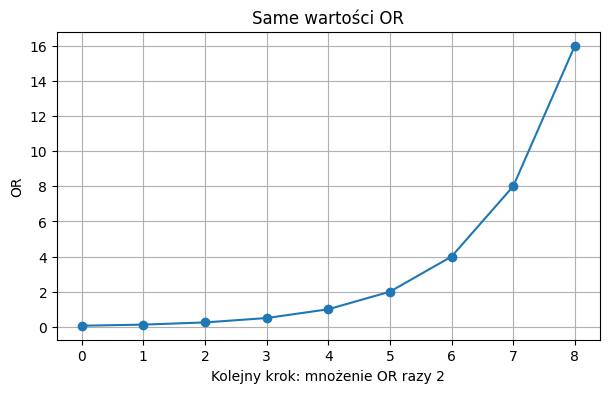

In [25]:
plt.figure(figsize=(7, 4))
plt.plot(value_table['step'], value_table['OR'], marker='o')
plt.xlabel('Kolejny krok: mnożenie OR razy 2')
plt.ylabel('OR')
plt.title('Same wartości OR')
plt.grid(True)
plt.show()

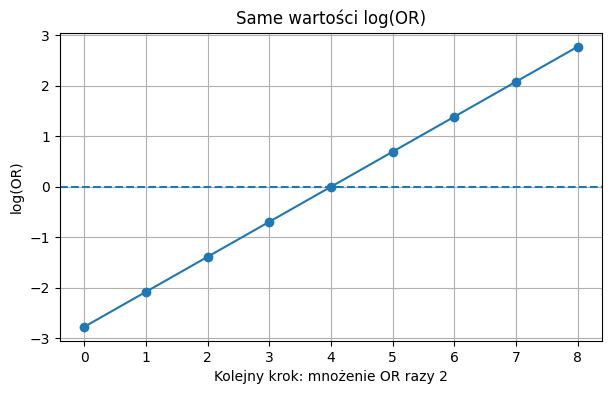

In [26]:
plt.figure(figsize=(7, 4))
plt.plot(value_table['step'], value_table['log(OR)'], marker='o')
plt.axhline(0, linestyle='--')
plt.xlabel('Kolejny krok: mnożenie OR razy 2')
plt.ylabel('log(OR)')
plt.title('Same wartości log(OR)')
plt.grid(True)
plt.show()

### 8.9. Regresja logistyczna i log-odds

Regresja logistyczna formalizuje tę samą intuicję.

Nie modeluje bezpośrednio prawdopodobieństwa jako linii prostej. Modeluje liniowo **log-odds**:

$$
\log\left(\frac{p}{1-p}\right) = \beta_0 + \beta_1 \cdot StudyHours
$$

Dlatego `log_odds` rosną liniowo, natomiast `odds` i prawdopodobieństwo zmieniają się nieliniowo.

In [27]:
log_full = LogisticRegression(max_iter=1000)
log_full.fit(X_small, y_pass)

beta_0 = log_full.intercept_[0]
beta_1 = log_full.coef_[0][0]

coef_table = pd.DataFrame({
    'parametr': ['beta_0', 'beta_1', 'exp(beta_1)'],
    'wartość': [beta_0, beta_1, np.exp(beta_1)]
})

coef_table

,parametr,wartość
0,beta_0,-16.1034
1,beta_1,1.5587
2,exp(beta_1),4.7525


In [28]:
hours_grid = np.array([6, 8, 10, 12, 14, 16])
log_odds_grid = beta_0 + beta_1 * hours_grid
odds_grid = np.exp(log_odds_grid)
prob_grid = odds_grid / (1 + odds_grid)

logistic_values = pd.DataFrame({
    'StudyHours': hours_grid,
    'probability': prob_grid,
    'odds': odds_grid,
    'log_odds': log_odds_grid
})

logistic_values

,StudyHours,probability,odds,log_odds
0,6,0.0012,0.0012,-6.7513
1,8,0.0257,0.0264,-3.6339
2,10,0.3737,0.5966,-0.5166
3,12,0.9309,13.4742,2.6008
4,14,0.9967,304.3351,5.7181
5,16,0.9999,6873.8870,8.8355


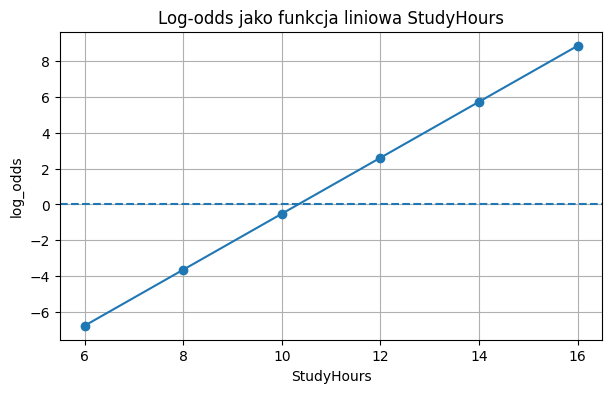

In [29]:
plt.figure(figsize=(7, 4))
plt.plot(logistic_values['StudyHours'], logistic_values['log_odds'], marker='o')
plt.axhline(0, linestyle='--')
plt.xlabel('StudyHours')
plt.ylabel('log_odds')
plt.title('Log-odds jako funkcja liniowa StudyHours')
plt.grid(True)
plt.show()

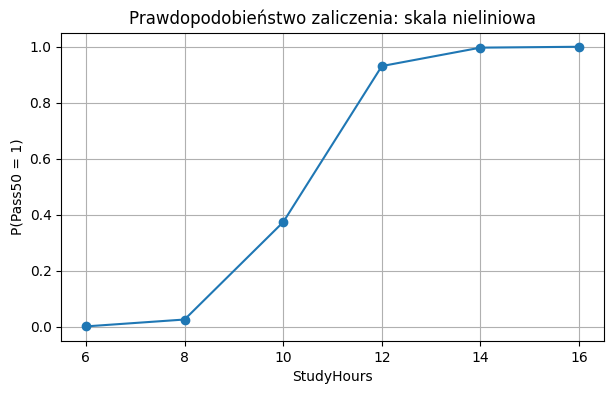

In [30]:
plt.figure(figsize=(7, 4))
plt.plot(logistic_values['StudyHours'], logistic_values['probability'], marker='o')
plt.xlabel('StudyHours')
plt.ylabel('P(Pass50 = 1)')
plt.title('Prawdopodobieństwo zaliczenia: skala nieliniowa')
plt.ylim(-0.05, 1.05)
plt.grid(True)
plt.show()

Najważniejszy wniosek z tej mini analizy:

- `odds` i `OR` są wygodne interpretacyjnie, bo mówią „ile razy większe są szanse/odds”,
- `log(OR)` i `log_odds` są wygodne modelowo, bo zamieniają mnożenie na dodawanie,
- dlatego regresja logistyczna używa liniowego modelu dla `log_odds`, a nie dla samego prawdopodobieństwa.

## 9. Checklista pipeline'u

Przed każdym modelem sprawdź:

1. Co jest targetem $y$?
2. Jakie cechy są dostępne przed predykcją?
3. Jaki jest baseline?
4. Jaki mamy podział train/test albo CV?
5. Jaką metrykę optymalizujemy?
6. Czy żadna cecha nie przecieka z targetu?
7. Czy wynik jest stabilny na kilku podziałach?

## Proste ćwiczenia

1. Wskaż baseline dla regresji i klasyfikacji w tym notebooku.
2. Dlaczego model z `GradeAfterExam_LEAK` ma bardzo dobre AUC?
3. Co może pójść źle, jeśli wybierzemy cechy na całym zbiorze przed podziałem train/test?
4. Zmień `test_size` z `0.25` na `0.4`. Czy wyniki są identyczne?
5. W mini analizie danych z poprzednich zajęć: dlaczego przy progu `StudyHours >= 10` pojawia się problem dzielenia przez zero przy odds ratio?